## <center><b> А/А-тестирование </b></center>

Данные, с которыми мы работаем, предварительно были разделены на несколько групп с помощью хэширования с солью. Известно, что данный метод обеспечивает случайность и детерминированность разбиения, а также примерно одинаковые размеры тестовой и контрольной групп. Перед тем, как переходить к непосредственному тестированию, необходимо проверить, насколько корректно функционирует система разделения трафика. Для этого проведем <b> А/А-тестирование </b> на выделенных группах пользователей.

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
df = pd.read_csv('data/aa_test.csv')

In [8]:
df.head(3)

,exp_group,user_id,likes,views,ctr
0,2,120469,6,34,0.176471
1,3,20264,5,39,0.128205
2,2,126891,28,112,0.250000


In [9]:
df.isnull().sum()

exp_group    0
user_id      0
likes        0
views        0
ctr          0
dtype: int64

In [121]:
df.groupby(by='exp_group')['likes'].agg(func='count')

exp_group
2    8480
3    8569
Name: likes, dtype: int64

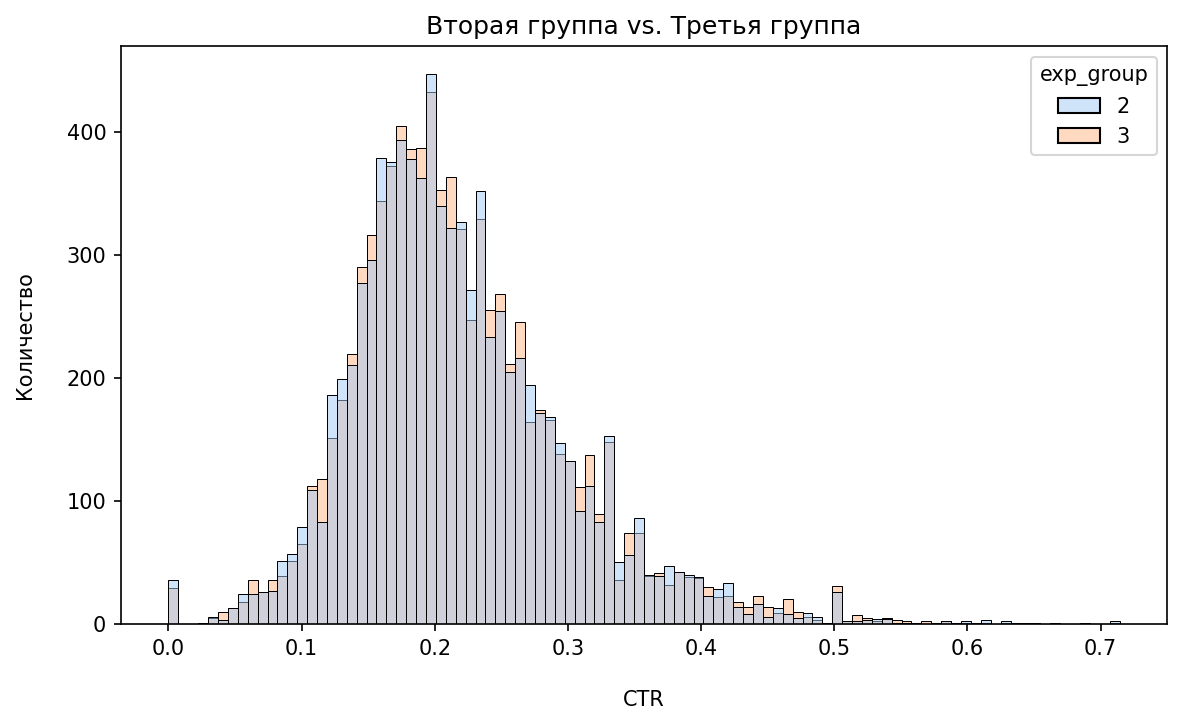

In [124]:
plt.figure(figsize=(9, 5), dpi=150)
sns.histplot(data=df, x='ctr', hue='exp_group', palette='pastel')
plt.title('Вторая группа vs. Третья группа')
plt.xlabel('\nCTR')
plt.ylabel('Количество\n')
plt.show()

Кажется, что группы из нашей система сплитования действительно являются статистически эквивалентными. Чтобы строго проверить это утверждение, недостаточно запустить <b> А/А-тест </b> на наших группах один раз, и, получив <b>p-value < $\alpha = 0.05$</b>, заключить его корректность. Поэтому проведем множественное сэмплирование из имеющихся у нас групп, чтобы описать результаты <b> A/A-тестирования</b>.

### <b>1. T-тест Стьюдента</b>

In [106]:
from scipy.stats import ttest_ind
from pingouin import qqplot

In [107]:
first_sample = df[df['exp_group'] == 2]
second_sample = df[df['exp_group'] == 3]

In [108]:
n_iterations, n_observations = 20_000, 500
p_values, false_positives = [], 0

In [109]:
for idx in range(n_iterations):

    resample1 = first_sample['ctr'].sample(n=n_observations, replace=False, random_state=idx)
    resample2 = second_sample['ctr'].sample(n=n_observations, replace=False, random_state=idx)

    test = ttest_ind(resample1.values, resample2.values)
    if test.pvalue < 0.05:
        false_positives += 1
    p_values.append(test.pvalue)

In [111]:
print(f'False Positive Rate = {false_positives / n_iterations}')

False Positive Rate = 0.0455


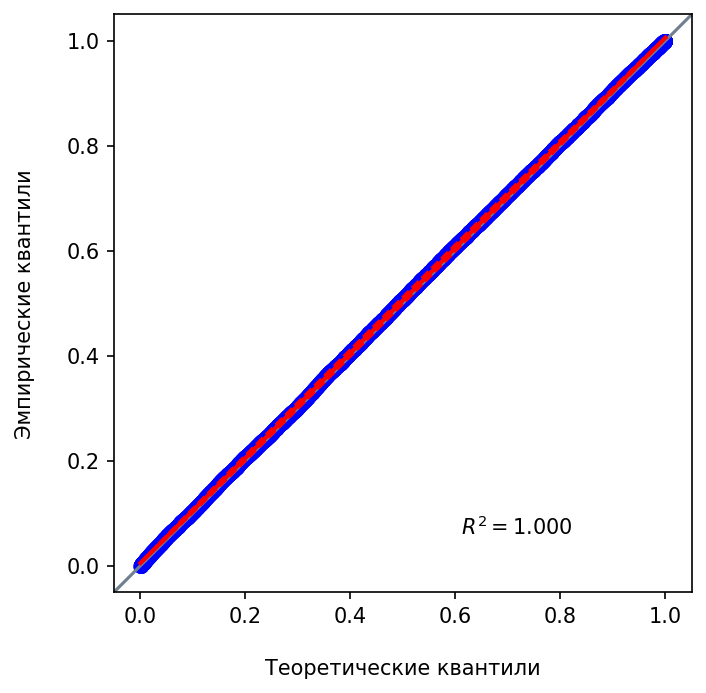

In [110]:
plt.figure(figsize=(5, 5), dpi=150)
qqplot(x=p_values, dist='uniform')
plt.xlabel('\nТеоретические квантили')
plt.ylabel('Эмпирические квантили\n')
plt.show()

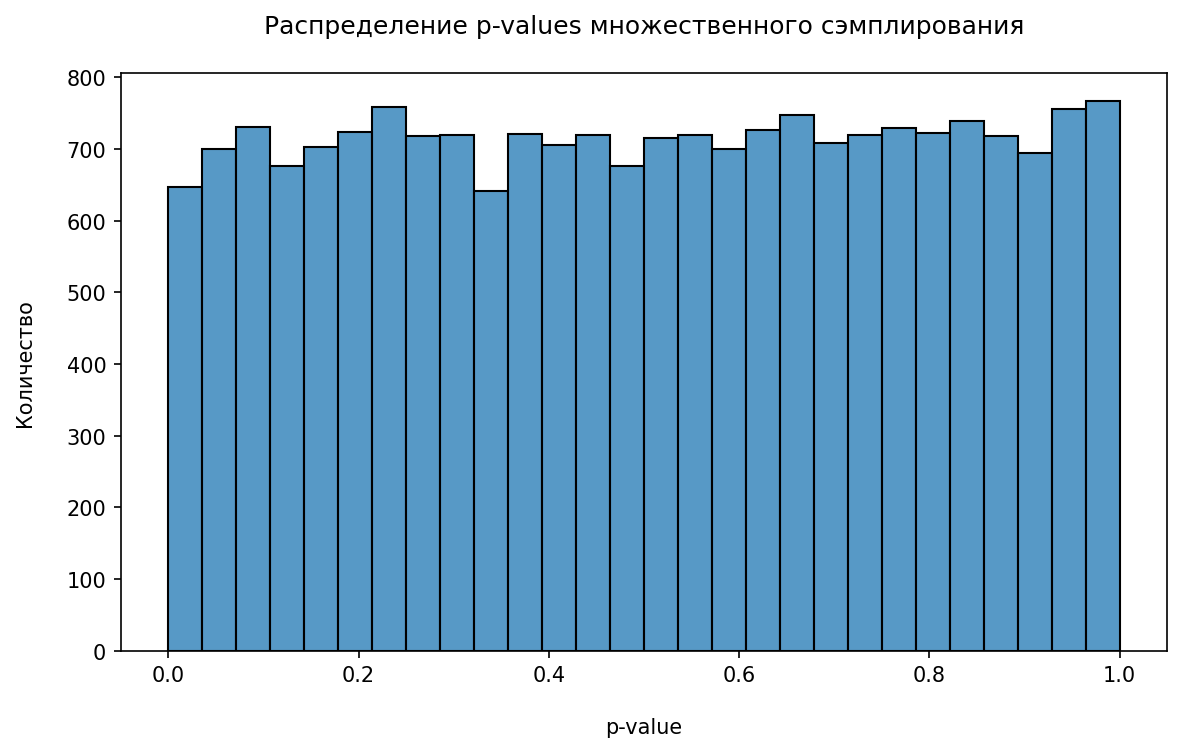

In [113]:
plt.figure(figsize=(9, 5), dpi=150)
sns.histplot(data=p_values)
plt.title('Распределение p-values множественного сэмплирования\n')
plt.xlabel('\np-value')
plt.ylabel('Количество\n')
plt.show()

Так, моделирование показывает, что распределение <b>p-values</b> стремится к равномерному, а <b>False Positive Rate</b> отклоняется незначительно от заданного уровня значимости. Важно, что в общем случае опираться на <b>T-критерий Стьюдента</b> неправильно, так как ошибка первого рода может систематически завышаться в силу нарушающихся предположений о распределении наших данных. Для более справедливой проверки, воспользуемся непараметрическим аналогом <b>T-теста Стьюдента</b> - <b>U-тестом Манна-Уитни</b>.

### <b>2. U-тест Манна-Уитни</b>

Вспомним, что основная метрика нашего теста - <b> CTR </b>. Она имеет характеристики, которые могут нарушить предположения, необходимые для корректной работы <b> t-теста </b>:
1. <div style="font-size: 16px;"> <b>Ненормальность</b> распределения</div>
2. <div style="font-size: 16px;"> Наличие <b>выбросов</b></div>
 
Очевидно, что в общем случае эти предположения не соблюдаются, поэтому результаты<b> t-теста </b>могут быть ненадежными. Для дополнительной уверенности в наших выводах проведем параллельный анализ с использованием <b>U-теста Манна-Уитни</b>, который не требует предположений о нормальности и более устойчив к выбросам.

In [114]:
from scipy.stats import mannwhitneyu

In [115]:
n_iterations, n_observations = 20_000, 500
p_values_u, false_positives_u = [], 0

In [116]:
for idx in range(n_iterations):

    resample1 = first_sample['ctr'].sample(n=n_observations, replace=False, random_state=idx)
    resample2 = second_sample['ctr'].sample(n=n_observations, replace=False, random_state=idx)

    test = mannwhitneyu(resample1.values, resample2.values)
    if test.pvalue < 0.05:
        false_positives_u += 1
    p_values_u.append(test.pvalue)

In [118]:
print(f'False Positive Rate = {false_positives_u / n_iterations}')

False Positive Rate = 0.04475


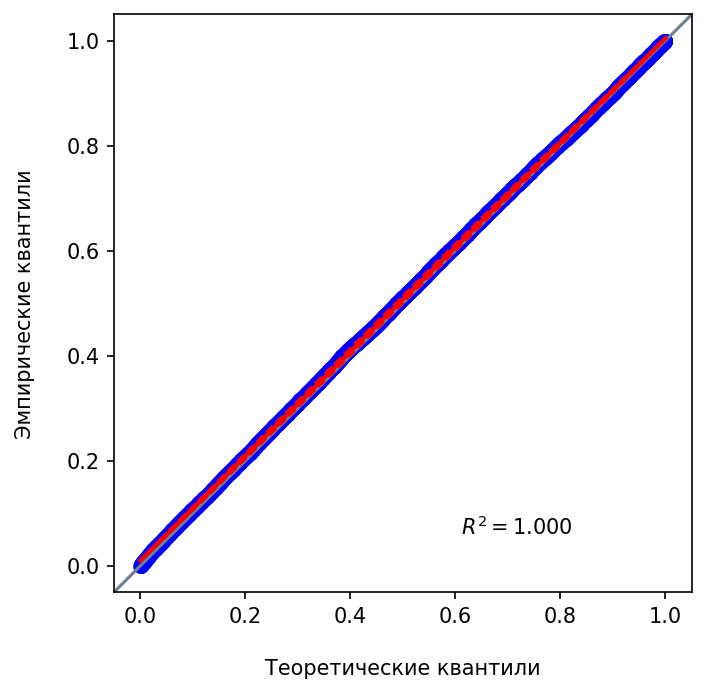

In [119]:
plt.figure(figsize=(5, 5), dpi=150)
qqplot(x=p_values_u, dist='uniform')
plt.xlabel('\nТеоретические квантили')
plt.ylabel('Эмпирические квантили\n')
plt.show()

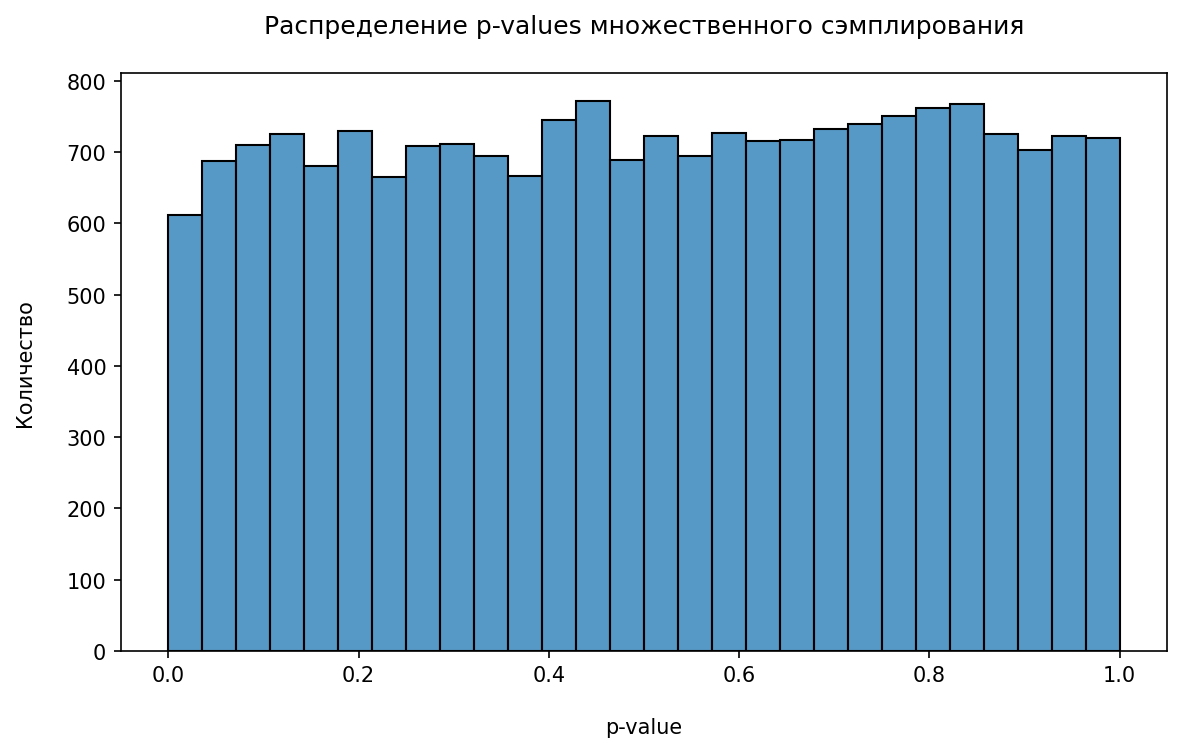

In [117]:
plt.figure(figsize=(9, 5), dpi=150)
sns.histplot(data=p_values_u)
plt.title('Распределение p-values множественного сэмплирования\n')
plt.xlabel('\np-value')
plt.ylabel('Количество\n')
plt.show()

### <b>Вывод</b>

Таким образом, построенные на основе моделирования распределения p-values имеют практически равномерное распределение. В свою очередь, эмпирический уровень ложно-положительных срабатываний <b> FPR ≈ 0.05 </b>. Значит, наша система сплитования не создает статистически значимых различий между идентичными группами чаще, чем это допускается выбранным уровнем значимости <b> α = 0.05</b>. Будем считать <b>A/A-тест</b> пройденным успешно - система сплитования работает корректно. 